In [25]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

In [3]:
os.chdir(r"C:/Users/jakes/Downloads")

In [5]:
df = pd.read_csv("nyc_housing_base.csv")

In [7]:
df.head()

,borough_x,block,lot,sale_price,zip_code,borough_y,yearbuilt,lotarea,bldgarea,resarea,comarea,unitsres,unitstotal,numfloors,latitude,longitude,landuse,bldgclass,building_age
0,1,400,11,280000,10009.0,MN,1900.0,2404.0,6875.0,6875.0,0.0,18.0,18.0,5.0,40.724415,-73.983891,2.0,C6,125.0
1,1,402,36,2000000,10009.0,MN,1900.0,1919.0,7810.0,6810.0,1000.0,8.0,10.0,5.0,40.724975,-73.981535,2.0,C4,125.0
2,1,402,60,3400000,10009.0,MN,1920.0,2150.0,6152.0,5352.0,800.0,8.0,9.0,5.0,40.725346,-73.983112,4.0,C7,105.0
3,1,404,42,4000000,10009.0,MN,1855.0,2369.0,6990.0,6990.0,0.0,10.0,10.0,5.0,40.727398,-73.980600,2.0,C4,170.0
4,1,372,55,655000,10009.0,MN,1920.0,5298.0,17990.0,17990.0,0.0,20.0,20.0,5.0,40.720621,-73.979534,2.0,C6,105.0


In [9]:
df = df.dropna()

In [11]:
df.shape

(34203, 19)

In [13]:
df['unitsres'].max()

1887.0

In [17]:
# Cleaning
cols = ["sale_price", "unitsres", "resarea"]
for col in cols:
    df[col] = pd.to_numeric(df[col], errors = "coerce")

df = df.dropna(subset = cols)

df = df[(df["sale_price"] > 0) & (df["unitsres"] > 0) & (df["resarea"] > 0)]

In [19]:
# Calculating price per sq ft

df["price_per_sqft"] = df["sale_price"] / df["resarea"]

In [21]:
# Removing outliers

df = df[df["price_per_sqft"] < df["price_per_sqft"].quantile(0.99)]
df = df[df["unitsres"] < df["unitsres"].quantile(0.99)]

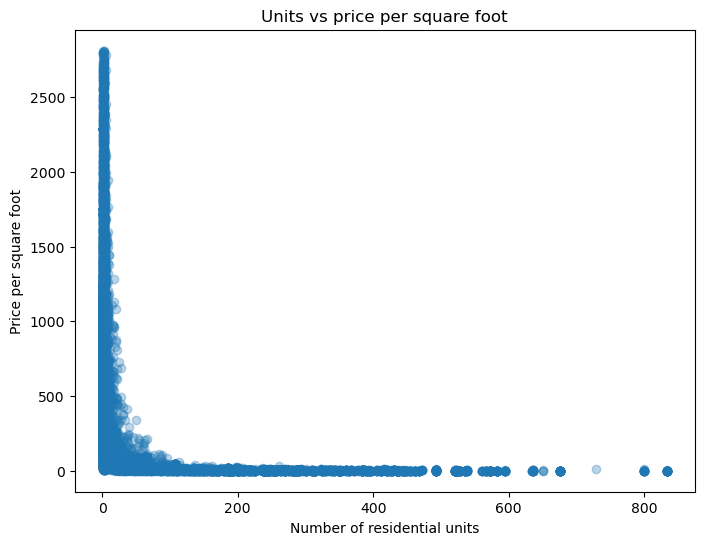

In [37]:
# Plots for visualization

plt.figure(figsize = (8,6))
plt.scatter(df["unitsres"], df["price_per_sqft"], alpha = 0.3)
plt.xlabel("Number of residential units")
plt.ylabel("Price per square foot")
plt.title("Units vs price per square foot")
plt.savefig("units_vs_price_per_square_foot.png", dpi = 300, bbox_inches = "tight")
plt.show()

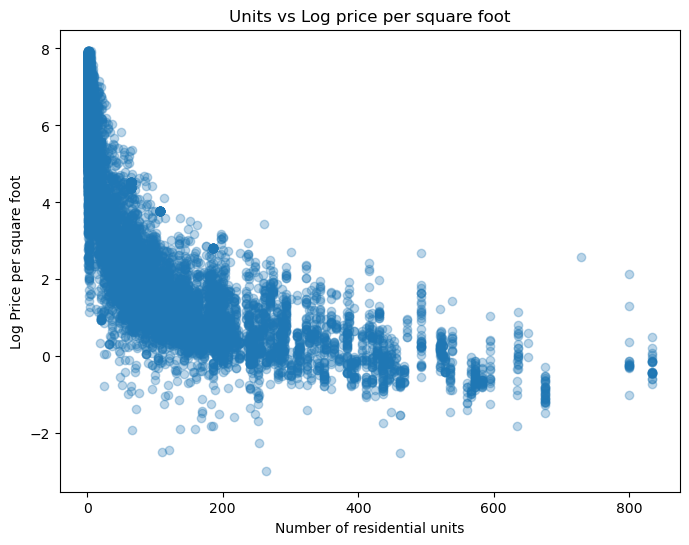

In [39]:
# Log transformed price per sqft

plt.figure(figsize = (8,6))
plt.scatter(df["unitsres"], np.log(df["price_per_sqft"]), alpha = 0.3)
plt.xlabel("Number of residential units")
plt.ylabel("Log Price per square foot")
plt.title("Units vs Log price per square foot")
plt.savefig("Units vs log price per sqaure foot.png", dpi = 300, bbox_inches = "tight")
plt.show()

C:\Users\jakes\AppData\Local\Temp\ipykernel_8884\1179337571.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg = df.groupby("units_bins")["price_per_sqft"].mean()


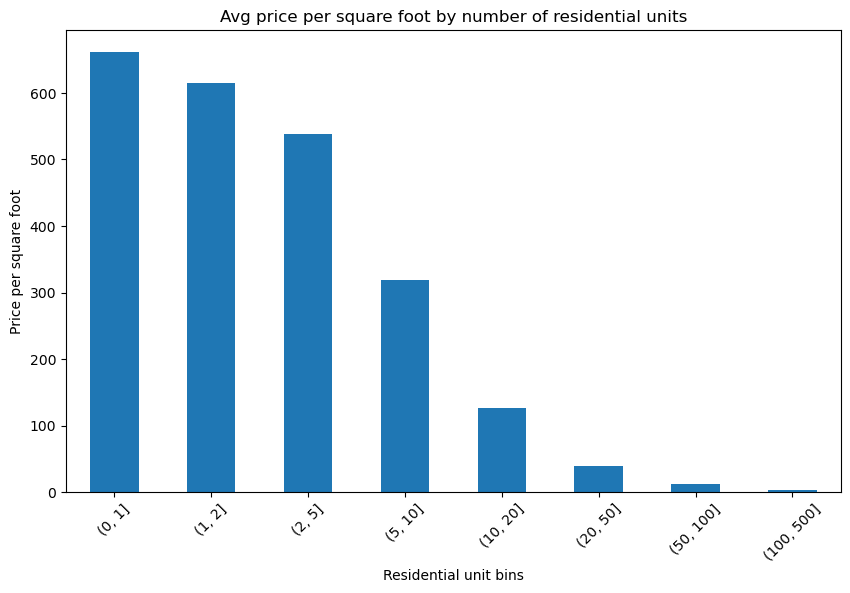

In [41]:
# Binning the amount of residential units

df["units_bins"] = pd.cut(df["unitsres"], bins = [0, 1, 2, 5, 10, 20, 50, 100, 500])

avg = df.groupby("units_bins")["price_per_sqft"].mean()

avg.plot(kind = "bar", figsize = (10,6))
plt.title("Avg price per square foot by number of residential units")
plt.ylabel("Price per square foot")
plt.xlabel("Residential unit bins")
plt.xticks(rotation = 45)
plt.savefig("Units vs price per sqaure foot bins.png", dpi = 300, bbox_inches = "tight")
plt.show()